# Step 02 - Scoring and Statistical Tests

This notebook runs the Step 2 pipeline: sample step-feature pairs, score latent verbal alignment (LVA), compute baselines, and run hypothesis checks.

1. Clone/pull from GitHub and set up imports
2. Load Step 1 checkpoint table to get all compiled (feature,step text) pairs
3. Build scoring sample
4. Run scoring and save checkpoints
5. Run diagnostics and hypothesis tests

In [ ]:
# Cell 1 - GitHub setup + imports
import subprocess
import sys
import os
from pathlib import Path

import pandas as pd

REPO_URL = "https://github.com/shreetishresthanp/latent_verbal_gap.git"
WORKDIR = Path("/content")
REPO_NAME = REPO_URL.rstrip("/").split("/")[-1].removesuffix(".git")
REPO = WORKDIR / REPO_NAME

# Keep the notebook reproducible: update an existing clone, otherwise clone fresh.
if REPO.exists():
    subprocess.run(["git", "-C", str(REPO), "pull", "--ff-only"], check=True)
    print(f"Updated existing repo: {REPO}")
else:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO)], check=True)
    print(f"Cloned repo: {REPO}")

REQ_FILE = REPO / "requirements.txt"
SRC_DIR = REPO / "src"

if REQ_FILE.exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(REQ_FILE)],
        check=True,
    )
else:
    print(f"Skipping install: missing {REQ_FILE}")

src_path = str(SRC_DIR)
if src_path not in sys.path:
    sys.path.insert(0, src_path)


Updated existing repo: /content/latent_verbal_gap
Skipping install: missing /content/latent_verbal_gap/requirements.txt


In [ ]:
import config, scoring, segmentation, utils
from config import CACHE_DIR
from scoring import (
    apply_label_filter,
    compute_baselines,
    compute_step_lva,
    run_consistency_check,
    run_h1_tests,
    run_scoring,
    stratified_step_sample,
    flag_generic_features
)
from utils import connect_dbs, load_seq_ids

# Load core inputs produced by Step 1.
conn = connect_dbs()
step_feat_df = pd.read_parquet(CACHE_DIR / "step_feat_df_step1_maxpool_k3_lnorm.parquet")
print(f"Using src at: {SRC_DIR}")
print(f"CACHE_DIR: {CACHE_DIR}")

In [4]:
# Quick sanity check: Step 1 checkpoint should be long-format with top-k rows per step.
print(step_feat_df.shape)
step_feat_df.head(10)

(64554, 12)


,sequence_id,step_idx,start_token,end_token,step_text,step_type,rel_step_pos,feature_rank,feature_id,feature_label,strength,strength_w
0,1000,0,64,76,"Alright, let's tackle this physics problem.",setup_planning,0.000000,1,26742,Mathematical problem-solving with formal notation,3.125000,0.373134
1,1000,0,64,76,"Alright, let's tackle this physics problem.",setup_planning,0.000000,2,22966,Beginning of mathematical problem-solving thou...,2.718750,0.324627
2,1000,0,64,76,"Alright, let's tackle this physics problem.",setup_planning,0.000000,3,10219,Mathematical word problems requiring calculati...,2.531250,0.302239
3,1000,1,76,98,The question is asking what magnitude force Jo...,other,0.006993,1,15072,Mathematical reasoning and step-by-step proble...,2.906250,0.358382
4,1000,1,76,98,The question is asking what magnitude force Jo...,other,0.006993,2,26742,Mathematical problem-solving with formal notation,2.640625,0.325626
5,1000,1,76,98,The question is asking what magnitude force Jo...,other,0.006993,3,10124,Mathematical calculation and step-by-step prob...,2.562500,0.315992
6,1000,2,98,122,"The options are given from A to E, with variou...",other,0.013986,1,15072,Mathematical reasoning and step-by-step proble...,2.921875,0.365949
7,1000,2,98,122,"The options are given from A to E, with variou...",other,0.013986,2,9212,Multiple-choice math problems with options A to E,2.593750,0.324853
8,1000,2,98,122,"The options are given from A to E, with variou...",other,0.013986,3,26296,Multiple-choice answer options in mathematical...,2.468750,0.309198
9,1000,3,122,132,"First, I need to visualize the problem.",setup_planning,0.020979,1,26742,Mathematical problem-solving with formal notation,3.500000,0.410256


In [5]:
steps_per_seq = step_feat_df.groupby("sequence_id")["step_idx"].nunique()
print(f"min={steps_per_seq.min()}, max={steps_per_seq.max()}, mean={steps_per_seq.mean():.1f}")

min=8, max=798, mean=231.4


In [ ]:
# Keeping exactly top-3 feature rows per step for scoring comparability.
step_feat_df = step_feat_df[step_feat_df["feature_rank"] <= 3].copy()
print(step_feat_df["feature_rank"].value_counts().sort_index())
print(f"\nTotal rows: {len(step_feat_df):,}")
print(f"Unique steps: {step_feat_df[['sequence_id','step_idx']].drop_duplicates().shape[0]:,}")

feature_rank
1    21518
2    21518
3    21518
Name: count, dtype: int64

Total rows: 64,554
Unique steps: 21,518


In [6]:
from config import N_SAMPLE_STEPS
print(f"N_SAMPLE_STEPS: {N_SAMPLE_STEPS}")
print(f"Expected scoring_df size after sample: ~{N_SAMPLE_STEPS * 3:,} pairs")

N_SAMPLE_STEPS: 2000
Expected scoring_df size after sample: ~6,000 pairs


In [ ]:
# Recreating the scoring sample from the Step 1 checkpoint.
scoring_df = pd.read_parquet(CACHE_DIR / "step_feat_df_step1_maxpool_k3_lnorm.parquet")
from scoring import stratified_step_sample

sampled_steps = stratified_step_sample(scoring_df)
scoring_df = scoring_df.merge(sampled_steps, on=["sequence_id", "step_idx"])
print(f"scoring_df: {len(scoring_df):,} pairs")

scoring_df: 5,994 pairs


In [5]:
# Sample steps stratified by step_type, then expand each step to its top-k feature pairs.
sampled_steps = stratified_step_sample(step_feat_df)
scoring_df = step_feat_df.merge(sampled_steps, on=["sequence_id", "step_idx"])

print(f"scoring_df: {len(scoring_df):,} pairs")
print(f"Unique steps: {scoring_df[['sequence_id','step_idx']].drop_duplicates().shape[0]:,}")
print(f"\nStep type distribution:")
print(scoring_df.drop_duplicates(["sequence_id", "step_idx"])["step_type"].value_counts().to_string())

scoring_df: 5,994 pairs
Unique steps: 1,998

Step type distribution:
step_type
other              939
calculation        574
setup_planning     170
self_correction    168
uncertainty        147


In [8]:
# Diagnostic: verify whether longer steps systematically have larger raw strengths.
step_summary = (
    scoring_df
    .drop_duplicates(["sequence_id", "step_idx"])
    .assign(step_length=lambda df: df["end_token"] - df["start_token"])
)

from scipy.stats import spearmanr
r, p = spearmanr(
    step_summary["step_length"],
    scoring_df.groupby(["sequence_id", "step_idx"])["strength"].mean().reset_index()["strength"],
)
print(f"Step length vs mean strength: r={r:.3f}, p={p:.4f}")

Step length vs mean strength: r=0.519, p=0.0000


In [9]:
step_feat_df.describe()

,sequence_id,step_idx,start_token,end_token,rel_step_pos,feature_rank,feature_id,strength,strength_w
count,64554.000000,64554.000000,64554.000000,64554.000000,64554.000000,64554.000000,64554.000000,64554.000000,64554.000000
mean,44332.558788,174.903104,4460.250302,4485.090436,0.500000,2.000000,16131.061452,2.869334,0.333333
std,25643.203978,152.367605,3682.791370,3683.318649,0.289933,0.816503,7917.255315,0.877939,0.099199
min,1000.000000,0.000000,22.000000,51.000000,0.000000,1.000000,40.000000,1.023438,0.133462
25%,24000.000000,58.000000,1508.000000,1534.000000,0.248848,1.000000,10274.000000,2.125000,0.252991
50%,40000.000000,130.000000,3429.500000,3458.000000,0.500000,2.000000,15072.000000,2.750000,0.303179
75%,67000.000000,252.000000,6558.000000,6582.000000,0.751152,3.000000,22964.000000,3.656250,0.416275
max,93000.000000,797.000000,16456.000000,16463.000000,1.000000,3.000000,28660.000000,5.000000,0.637555


In [10]:
print(step_feat_df.groupby("feature_rank")["feature_label"]
      .value_counts()
      .groupby(level=0)
      .head(10)
      .to_string())

feature_rank  feature_label                                                         
1             Mathematical reasoning and step-by-step problem solving                   19001
              Mathematical problem-solving with formal notation                          2281
              Mathematical variables and symbols in word problems                         209
              Mathematical problem-solving and counting                                     9
              Beginning of mathematical problem-solving thought process                     4
              Mathematical problem-solving and step-by-step calculations                    3
              Mathematical reasoning with prime numbers and divisibility tests              2
              Assistant's turn to respond to mathematical problems                          1
              Diophantine equations and integer solution methods                            1
              Functional equations and additive functions in mathemat

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv() # Load variables from .env
os.environ("ANTHROPIC_API_KEY") = os.getenv("ANTHROPIC_API_KEY") 

In [10]:
import anthropic
client = anthropic.Anthropic()
resp = client.messages.create(
    model="claude-haiku-4-5",
    max_tokens=50,
    messages=[{"role": "user", "content": "hi"}]
)
print(resp.content[0].text)

Hey there! 👋 How's it going? What can I help you with?


In [24]:
import time
time.sleep(60)

# Test single call
result = judge_pair("x = 5 + 3 = 8", "Step-by-step mathematical calculations")
print(result)

{'score': 0.8, 'confidence': 'high', 'reasoning': 'The step performs a direct arithmetic calculation (5 + 3 = 8) which is exactly the type of step-by-step mathematical operation the label describes, though the label is somewhat general rather than specific to this particular arithmetic operation.'}


In [12]:
import os
for f in [
    CACHE_DIR / "lva_consistency_run1.parquet",
    CACHE_DIR / "lva_consistency_rescore.parquet",
]:
    if f.exists():
        os.remove(f)
        print(f"Deleted {f}")

r = run_consistency_check(
    scoring_df,
    cache_path=CACHE_DIR / "lva_consistency_rescore.parquet",
    force=True,
)
assert r >= 0.8, f"Judge r={r:.3f}"

Deleted /content/drive/MyDrive/latent_verbal_gap/checkpoints/lva_consistency_run1.parquet
Deleted /content/drive/MyDrive/latent_verbal_gap/checkpoints/lva_consistency_rescore.parquet


Consistency run 2: 100%|██████████| 59/59 [01:06<00:00,  1.12s/it]


Judge consistency (n=53):  r=0.980  p=1.61e-37
  ✓ r >= 0.8 — judge reliable, proceed


In [14]:
run1 = pd.read_parquet(CACHE_DIR / "lva_consistency_run1.parquet")
run2 = pd.read_parquet(CACHE_DIR / "lva_consistency_rescore.parquet")

print(f"Run 1: {len(run1)} rows, errors: {(run1['lva_score'] < 0).sum()}")
print(f"Run 2: {len(run2)} rows, errors: {(run2['lva_score'] < 0).sum()}")

merged = run1.merge(
    run2.rename(columns={"lva_score": "lva_score_r2"}),
    on=["sequence_id", "step_idx", "feature_id"],
    how="inner"
)
print(f"\nMerged rows: {len(merged)}")
print(f"Valid (both >= 0): {((merged['lva_score'] >= 0) & (merged['lva_score_r2'] >= 0)).sum()}")
print(f"\nRun 1 sample:")
print(run1.head(5))

Run 1: 59 rows, errors: 0
Run 2: 59 rows, errors: 6

Merged rows: 59
Valid (both >= 0): 53

Run 1 sample:
   sequence_id  step_idx  feature_id  lva_score
0        39000       204        7464        0.2
1        83000        99       26742        0.3
2        47000       158       15072        0.4
3        52000       308       22964        0.6
4        26000       145       22964        0.7


In [ ]:
# Running full scoring pipeline
scores_df = run_scoring(
    scoring_df,
    cache_path=CACHE_DIR / "lva_scores_raw_k3_lnorm.parquet",
    force=False,  
    max_workers=3,
)

Local Run scoring called
Resuming from checkpoint: 4600 rows already done


LVA scoring: 100%|██████████| 1394/1394 [43:19<00:00,  1.87s/it] 

Saved 5,994 scored rows


In [16]:
errors = (scores_df["lva_score"] < 0).sum()
print(f"Total rows: {len(scoring_df):,}")
print(f"Errors: {errors} ({100*errors/len(scores_df):.1f}%)")

Total rows: 5,994
Errors: 602 (10.0%)


In [17]:
errors_df = scores_df[scores_df["lva_score"] < 0]
print(errors_df["reasoning"].str[:80].value_counts().head(5))

reasoning
Error code: 429 - {'type': 'error', 'error': {'type': 'rate_limit_error', 'messa    588
Expecting ',' delimiter: line 1 column 282 (char 281)                                 1
Expecting ',' delimiter: line 1 column 215 (char 214)                                 1
Expecting ',' delimiter: line 1 column 250 (char 249)                                 1
Expecting ',' delimiter: line 1 column 301 (char 300)                                 1
Name: count, dtype: int64


In [ ]:
# Rescoring 602 failed rows
import time

# Add sleep to judge_pair for this retry run
import scoring as scoring_module

original_judge = scoring_module.judge_pair

def judge_pair_slow(step_text, feature_label):
    time.sleep(1.5)  # 40 RPM with 1 worker
    return original_judge(step_text, feature_label)

scoring_module.judge_pair = judge_pair_slow

# Get failed rows
failed_keys = scores_df[scores_df["lva_score"] < 0][["sequence_id", "step_idx", "feature_id"]]
failed_scoring_df = scoring_df.merge(failed_keys, on=["sequence_id", "step_idx", "feature_id"])
print(f"Rows to rescore: {len(failed_scoring_df):,}")

# Rescore
scores_retry = run_scoring(
    failed_scoring_df,
    cache_path=CACHE_DIR / "lva_scores_retry.parquet",
    force=True,
    max_workers=2,
)

print(f"Retry errors: {(scores_retry['lva_score'] < 0).sum()}")

Rows to rescore: 602
Local Run scoring called


LVA scoring: 100%|██████████| 602/602 [15:35<00:00,  1.55s/it]

Saved 602 scored rows
Retry errors: 1


In [19]:
successful_retry = scores_retry[scores_retry["lva_score"] >= 0]
scores_df_clean = pd.concat([
    scores_df[scores_df["lva_score"] >= 0],
    successful_retry
]).drop_duplicates(["sequence_id", "step_idx", "feature_id"])

print(f"Final clean rows: {len(scores_df_clean):,}")
print(f"Remaining errors: {len(scores_df) - len(scores_df_clean)}")

scores_df_clean.to_parquet(CACHE_DIR / "lva_scores_raw_k3_lnorm.parquet", index=False)

Final clean rows: 5,993
Remaining errors: 1


### Sample scored pairs post scoring

In [21]:
scores_df_clean.head(5)

,sequence_id,step_idx,rel_step_pos,step_type,feature_id,feature_label,feature_rank,strength,strength_w,lva_score,confidence,reasoning,step_text
0,1000,22,0.153846,self_correction,15072,Mathematical reasoning and step-by-step proble...,1,3.312500,0.418559,0.2,high,This step is a brief contextual observation ab...,"Wait, but the problem mentions a physics book."
1,1000,5,0.034965,setup_planning,26742,Mathematical problem-solving with formal notation,3,2.125000,0.272000,0.2,high,This step identifies a physical constraint and...,The key here is that the rope is in danger of ...
2,1000,5,0.034965,setup_planning,3477,Mathematical reasoning and calculation,2,2.203125,0.282000,0.3,high,The step identifies a physical constraint (rop...,The key here is that the rope is in danger of ...
3,1000,5,0.034965,setup_planning,15072,Mathematical reasoning and step-by-step proble...,1,3.484375,0.446000,0.4,high,The step identifies a physical constraint (pre...,The key here is that the rope is in danger of ...
4,1000,22,0.153846,self_correction,26742,Mathematical problem-solving with formal notation,2,2.875000,0.363277,0.1,high,The step is a brief clarification about proble...,"Wait, but the problem mentions a physics book."


In [ ]:
r = run_consistency_check(
    scoring_df,
    cache_path=CACHE_DIR / "lva_consistency_rescore.parquet",
    use_cache=True
)

Deleted: /content/drive/MyDrive/latent_verbal_gap/checkpoints/lva_consistency_run1.parquet
Deleted: /content/drive/MyDrive/latent_verbal_gap/checkpoints/lva_consistency_rescore.parquet


Consistency run 2: 100%|██████████| 99/99 [02:15<00:00,  1.37s/it]


Judge consistency (n=57):  r=0.976  p=3.86e-38
  ✓ r >= 0.8 — judge reliable, proceed


In [34]:
import os
if (CACHE_DIR / "lva_scores_test.parquet").exists():
    os.remove(CACHE_DIR / "lva_scores_test.parquet")

scores_df = run_scoring(
    scoring_df,
    cache_path=CACHE_DIR / "lva_scores_raw.parquet",
    max_workers=3
)

print(f"Total rows: {len(scores_df)}")
print(f"Errors: {(scores_df['lva_score'] < 0).sum()}")
print(f"\nScore distribution:")
print(scores_df[scores_df['lva_score'] >= 0]['lva_score'].describe().round(3))

LVA scoring: 100%|██████████| 9989/9989 [3:12:35<00:00,  1.16s/it]  

Saved 9,989 scored rows
Total rows: 9989
Errors: 487

Score distribution:
count    9502.000
mean        0.381
std         0.200
min         0.000
25%         0.200
50%         0.400
75%         0.400
max         0.950
Name: lva_score, dtype: float64


### H1 Tests

In [ ]:
# H1 tests
_scores_cache = CACHE_DIR / "lva_scores_raw.parquet"
try:
    scores_df
except NameError:
    if _scores_cache.exists():
        scores_df = pd.read_parquet(_scores_cache)
        print(f"Loaded scores_df from {_scores_cache} ({len(scores_df):,} rows)")
    else:
        raise RuntimeError(
            f"scores_df is not defined and no cache at {_scores_cache}. "
            "Run the scoring cell first."
        ) from None


Loaded scores_df from /content/drive/MyDrive/latent_verbal_gap/checkpoints/lva_scores_raw.parquet (9,989 rows)


In [11]:
scores_df.sort_values(by="lva_score", ascending=False).head(10)

,sequence_id,step_idx,rel_step_pos,step_type,feature_id,feature_label,feature_rank,strength,strength_w,label_quality,lva_score,confidence,reasoning
7157,61000,43,0.811321,other,2337,Mathematical and trigonometric identities and ...,5,1.757812,0.136778,0.90,0.95,high,The step explicitly states it uses trigonometr...
6847,56000,67,0.917808,calculation,3574,Final answer marker in mathematical problem so...,4,2.765625,0.174213,0.90,0.95,high,This step explicitly presents the final answer...
6845,56000,67,0.917808,calculation,28490,Final answer in mathematical problem-solving,3,2.859375,0.180118,0.95,0.95,high,This step explicitly presents the final answer...
1067,10000,47,0.219626,calculation,8138,Multiplicative inverses in modular arithmetic,5,2.187500,0.174346,0.95,0.95,high,The step directly computes and applies a multi...
83,1000,125,0.874126,other,17895,Identifying the correct answer in multiple-cho...,5,1.562500,0.115875,0.95,0.95,high,The step directly states a conclusion about wh...
4847,39000,87,0.277070,other,13815,Mathematical division remainders,5,1.703125,0.147696,0.95,0.95,high,The step explicitly defines the division remai...
7042,58000,169,0.933702,setup_planning,28490,Final answer in mathematical problem-solving,5,2.765625,0.162684,0.95,0.95,high,The step explicitly presents the final answer ...
100,2000,35,0.238095,other,2868,Verification that a mathematical solution sati...,3,1.414062,0.138910,0.95,0.95,high,The step explicitly verifies that all three eq...
1303,13000,74,0.300813,other,9322,Referencing the problem statement or prompt co...,5,1.562500,0.118413,0.90,0.95,high,The step directly references the problem state...
1232,12000,85,0.629630,other,14888,Reflection and mirroring concepts,5,1.593750,0.156442,0.90,0.95,high,The step directly invokes the concept of refle...


In [ ]:
step_lva = compute_step_lva(scores_df)
h1_df    = compute_baselines(scores_df)
run_h1_tests(h1_df)

# Save
step_lva.to_parquet(CACHE_DIR / "step_lva_scores.parquet", index=False)
h1_df.to_parquet(CACHE_DIR / "h1_comparison.parquet", index=False)

print(f"\nStep LVA shape: {step_lva.shape}")
print(f"\nStep type distribution:")
print(step_lva["step_type"].value_counts().to_string())
print(f"\nMean LVA by step type:")
print(step_lva.groupby("step_type")["lva_score"].mean().sort_values(ascending=False).round(3).to_string())


H1: Real LVA vs baselines

Random-feature:  real=0.371  base=0.382  t=-3.353  p=0.0008  d=-0.106  ✗ not significant

Step-shuffle:  real=0.371  base=0.371  t=0.000  p=1.0000  d=0.000  ✗ not significant

Cross-problem:  real=0.371  base=0.372  t=-0.058  p=0.9534  d=-0.005  ✗ not significant

Step LVA shape: (1998, 7)

Step type distribution:
step_type
other              939
calculation        574
setup_planning     170
self_correction    168
uncertainty        147

Mean LVA by step type:
step_type
calculation        0.407
setup_planning     0.394
uncertainty        0.383
self_correction    0.365
other              0.344


In [12]:
print(scores_df.columns.tolist())

['sequence_id', 'step_idx', 'rel_step_pos', 'step_type', 'feature_id', 'feature_label', 'feature_rank', 'strength', 'strength_w', 'label_quality', 'lva_score', 'confidence', 'reasoning']


In [17]:
scores_with_text = scores_df.merge(
    scoring_df[["sequence_id", "step_idx", "feature_id", "step_text"]],
    on=["sequence_id", "step_idx", "feature_id"],
    how="left"
)

# Now look at high scoring pairs
high_scores = scores_with_text[scores_with_text["lva_score"] >= 0.7].sort_values(
    "lva_score", ascending=False
).reset_index(drop=True)

print(f"Pairs scoring >= 0.7: {len(high_scores)}")
print(f"{'='*80}")
for i, row in high_scores.head(20).iterrows():
    print(f"\n--- Pair {i+1} | Score: {row['lva_score']} | Confidence: {row['confidence']} ---")
    print(f"STEP:    {row['step_text'][:300]}")
    print(f"LABEL:   {row['feature_label']}")
    print(f"REASON:  {row['reasoning']}")
    print(f"{'='*80}")

Pairs scoring >= 0.7: 1106

--- Pair 1 | Score: 0.95 | Confidence: high ---
STEP:    First, let me visualize the triangle.
LABEL:   geometric visualization in mathematical problem-solving
REASON:  The step explicitly states an intent to visualize a triangle, which is a geometric visualization activity directly matching the feature label's core meaning.

--- Pair 2 | Score: 0.95 | Confidence: high ---
STEP:    Therefore, E seems to be the correct answer.
LABEL:   Identifying the correct answer in multiple-choice questions
REASON:  The step directly states a conclusion about which answer choice is correct in what appears to be a multiple-choice context, making this a precise match for the feature label.

--- Pair 3 | Score: 0.95 | Confidence: high ---
STEP:    So all three equations are satisfied.
LABEL:   Verification that a mathematical solution satisfies all conditions
REASON:  The step explicitly verifies that all three equations are satisfied, which directly matches the feature labe

In [19]:
# What does the score distribution look like for HIGH quality features only?
high_qual = scores_with_text[
    (scores_with_text["lva_score"] >= 0) & 
    (scores_with_text["label_quality"] >= 0.9)  # stricter than 0.8
]
low_qual = scores_with_text[
    (scores_with_text["lva_score"] >= 0) & 
    (scores_with_text["label_quality"] < 0.9)
]

print(f"High quality (>=0.9): n={len(high_qual)}, mean={high_qual['lva_score'].mean():.3f}")
print(f"Lower quality (0.8-0.9): n={len(low_qual)}, mean={low_qual['lva_score'].mean():.3f}")

# Check what the top-scoring labels look like
print("\nTop 20 highest-scoring (step, feature) pairs:")
print(scores_with_text[scores_with_text["lva_score"] >= 0]
      .nlargest(20, "lva_score")
      [["step_text", "feature_label", "lva_score", "confidence"]]
      .to_string())

# Check what features are actually in the scored set
print("\nMost common feature labels in scored set:")
print(scores_with_text["feature_label"].value_counts().head(20).to_string())

High quality (>=0.9): n=8681, mean=0.382
Lower quality (0.8-0.9): n=821, mean=0.373

Top 20 highest-scoring (step, feature) pairs:
                                                                                                                                                                                          step_text                                                        feature_label  lva_score confidence
83                                                                                                                                                     Therefore, E seems to be the correct answer.          Identifying the correct answer in multiple-choice questions       0.95       high
100                                                                                                                                                           So all three equations are satisfied.   Verification that a mathematical solution satisfies all conditions       0.95       high
383     

In [20]:
# Separate generic vs specific features
GENERIC_LABELS = [
    "Mathematical reasoning and step-by-step problem solving",
    "Mathematical problem-solving with formal notation", 
    "Mathematical problem-solving and step-by-step calculations",
    "Unfinished mathematical problem-solving attempts",
    "Mathematical problem-solving and counting",
    "Mathematical reasoning and calculation",
    "Mathematical problem-solving reasoning",
    "mathematical problem-solving and reasoning",
    "Mathematical problem-solving and calculation",
    "Mathematical problem-solving and verification",
]

scores_specific = scores_df[
    ~scores_df["feature_label"].isin(GENERIC_LABELS) &
    (scores_df["lva_score"] >= 0)
]
scores_generic = scores_df[
    scores_df["feature_label"].isin(GENERIC_LABELS) &
    (scores_df["lva_score"] >= 0)
]

print(f"Generic label rows: {len(scores_generic)} ({100*len(scores_generic)/len(scores_df[scores_df['lva_score']>=0]):.1f}%)")
print(f"Specific label rows: {len(scores_specific)} ({100*len(scores_specific)/len(scores_df[scores_df['lva_score']>=0]):.1f}%)")
print(f"\nGeneric mean LVA:  {scores_generic['lva_score'].mean():.3f}")
print(f"Specific mean LVA: {scores_specific['lva_score'].mean():.3f}")

# Re-run H1 on specific features only
from scipy import stats as scipy_stats
import numpy as np

step_lva_specific = (
    scores_specific
    .groupby(["sequence_id", "step_idx"])
    .apply(lambda g: pd.Series({
        "lva_score":    (g["strength_w"] * g["lva_score"]).sum() / g["strength_w"].sum(),
        "rel_step_pos": g["rel_step_pos"].iloc[0],
        "step_type":    g["step_type"].iloc[0],
    }))
    .reset_index()
)

print(f"\nSteps with specific features: {len(step_lva_specific)}")
print(f"Mean LVA (specific only): {step_lva_specific['lva_score'].mean():.3f}")
print(f"\nMean LVA by step type (specific features):")
print(step_lva_specific.groupby("step_type")["lva_score"].mean()
      .sort_values(ascending=False).round(3).to_string())

Generic label rows: 5980 (62.9%)
Specific label rows: 3522 (37.1%)

Generic mean LVA:  0.345
Specific mean LVA: 0.442

Steps with specific features: 1850
Mean LVA (specific only): 0.439

Mean LVA by step type (specific features):
step_type
uncertainty        0.496
setup_planning     0.489
calculation        0.451
self_correction    0.440
other              0.414


/tmp/ipykernel_1850/3998149634.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [ ]:
# H1 on specific features only
from scipy import stats as scipy_stats
import numpy as np

# Build baselines from specific features only
h1_specific = compute_baselines(scores_specific)
run_h1_tests(h1_specific)


H1: Real LVA vs baselines

Random-feature:  real=0.439  base=0.445  t=-0.781  p=0.4349  d=-0.026  ✗ not significant

Step-shuffle:  real=0.439  base=0.439  t=0.000  p=1.0000  d=0.000  ✗ not significant

Cross-problem:  real=0.439  base=0.475  t=-1.825  p=0.0702  d=-0.169  ✗ not significant


In [22]:
# How much score variance is within-sequence vs between-sequence?
from scipy import stats as scipy_stats

# Within-sequence: does LVA vary across steps in the same trace?
within_var = step_lva_specific.groupby("sequence_id")["lva_score"].std().mean()
between_var = step_lva_specific.groupby("sequence_id")["lva_score"].mean().std()

print(f"Mean within-sequence std: {within_var:.3f}")
print(f"Between-sequence std of means: {between_var:.3f}")

# Is there ANY step where LVA is notably high vs the rest of the trace?
step_lva_specific_z = step_lva_specific.copy()
seq_means = step_lva_specific.groupby("sequence_id")["lva_score"].transform("mean")
seq_stds  = step_lva_specific.groupby("sequence_id")["lva_score"].transform("std")
step_lva_specific_z["lva_z"] = (step_lva_specific["lva_score"] - seq_means) / seq_stds.clip(lower=0.01)

print(f"\nSteps with z-score > 2 (unusually high within trace): "
      f"{(step_lva_specific_z['lva_z'] > 2).sum()}")
print(f"Steps with z-score < -2 (unusually low within trace): "
      f"{(step_lva_specific_z['lva_z'] < -2).sum()}")

# Score distribution shape
print(f"\nScore histogram:")
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
hist = pd.cut(scores_specific["lva_score"], bins=bins).value_counts().sort_index()
print(hist.to_string())

# What do the LOWEST scoring specific pairs look like?
print(f"\n--- 5 lowest scoring specific pairs ---")
lowest = scores_specific.merge(
    scoring_df[["sequence_id", "step_idx", "feature_id", "step_text"]],
    on=["sequence_id", "step_idx", "feature_id"], how="left"
).nsmallest(5, "lva_score")[["step_text", "feature_label", "lva_score", "reasoning"]]
for _, row in lowest.iterrows():
    print(f"\nScore: {row['lva_score']}")
    print(f"Step:  {row['step_text'][:200]}")
    print(f"Label: {row['feature_label']}")
    print(f"Why:   {row['reasoning']}")

Mean within-sequence std: 0.208
Between-sequence std of means: 0.095

Steps with z-score > 2 (unusually high within trace): 56
Steps with z-score < -2 (unusually low within trace): 7

Score histogram:
lva_score
(0.0, 0.1]    438
(0.1, 0.2]    545
(0.2, 0.3]    432
(0.3, 0.4]    704
(0.4, 0.5]     10
(0.5, 0.6]    371
(0.6, 0.7]    180
(0.7, 0.8]    359
(0.8, 0.9]    320
(0.9, 1.0]     90

--- 5 lowest scoring specific pairs ---

Score: 0.0
Step:  B is μ_k Mg, which is kinetic friction.
Label: Mathematical reasoning with prime numbers and divisibility tests
Why:   The step identifies kinetic friction as a force quantity; the label concerns prime numbers and divisibility—no conceptual overlap exists.

Score: 0.0
Step:  Which is impossible.
Label: Mathematical reasoning with prime numbers and divisibility tests
Why:   This step is a logical conclusion statement with no mathematical content, prime numbers, divisibility, or reasoning processes related to the stated feature label.

Score: 0.

In [23]:
# Test the bimodality hypothesis
from scipy.stats import gaussian_kde
import numpy as np

scores_valid = scores_specific[scores_specific["lva_score"] >= 0]["lva_score"]

# Split at 0.5 threshold
low_alignment  = scores_valid[scores_valid < 0.5]
high_alignment = scores_valid[scores_valid >= 0.5]

print(f"Low alignment (<0.5):  n={len(low_alignment):,} ({100*len(low_alignment)/len(scores_valid):.1f}%)")
print(f"High alignment (>=0.5): n={len(high_alignment):,} ({100*len(high_alignment)/len(scores_valid):.1f}%)")
print(f"\nLow mean:  {low_alignment.mean():.3f}")
print(f"High mean: {high_alignment.mean():.3f}")

# Are high-alignment pairs concentrated in certain step types?
scores_specific_labeled = scores_specific.copy()
scores_specific_labeled["aligned"] = scores_specific_labeled["lva_score"] >= 0.5

print(f"\nAlignment rate by step type:")
print(scores_specific_labeled.groupby("step_type")["aligned"]
      .mean().sort_values(ascending=False).round(3).to_string())

print(f"\nAlignment rate by feature rank:")
print(scores_specific_labeled.groupby("feature_rank")["aligned"]
      .mean().sort_values(ascending=False).round(3).to_string())

# Are high-alignment pairs concentrated in rank 1 features?
rank1 = scores_specific[scores_specific["feature_rank"] == 1]
rank_other = scores_specific[scores_specific["feature_rank"] > 1]
print(f"\nRank 1 features mean LVA:    {rank1['lva_score'].mean():.3f}")
print(f"Rank 2-5 features mean LVA:  {rank_other['lva_score'].mean():.3f}")

Low alignment (<0.5):  n=2,193 (62.3%)
High alignment (>=0.5): n=1,329 (37.7%)

Low mean:  0.256
High mean: 0.750

Alignment rate by step type:
step_type
uncertainty        0.498
setup_planning     0.470
self_correction    0.393
calculation        0.382
other              0.338

Alignment rate by feature rank:
feature_rank
3    0.394
5    0.391
4    0.380
2    0.314
1    0.278

Rank 1 features mean LVA:    0.378
Rank 2-5 features mean LVA:  0.443


In [24]:
# What are the most common rank 1 features?
print("Most common rank 1 feature labels:")
print(scores_specific[scores_specific["feature_rank"] == 1]["feature_label"]
      .value_counts().head(15).to_string())

print("\nMost common rank 1 feature labels (ALL scores_df including generic):")
print(scores_df[scores_df["feature_rank"] == 1]["feature_label"]
      .value_counts().head(15).to_string())

# LVA by rank — full breakdown
print("\nMean LVA by feature rank (specific features):")
print(scores_specific.groupby("feature_rank")["lva_score"]
      .agg(["mean", "std", "count"]).round(3).to_string())

# H1 restricted to rank 1 only
rank1_scores = scores_specific[scores_specific["feature_rank"] == 1]
rank1_step_lva = (
    rank1_scores[rank1_scores["lva_score"] >= 0]
    .groupby(["sequence_id", "step_idx"])
    .apply(lambda g: pd.Series({
        "lva_score":    (g["strength_w"] * g["lva_score"]).sum() / g["strength_w"].sum(),
        "rel_step_pos": g["rel_step_pos"].iloc[0],
        "step_type":    g["step_type"].iloc[0],
    }), include_groups=False)
    .reset_index()
)

# Compare rank 1 vs shuffled rank 1
from scipy import stats as scipy_stats
real_r1 = rank1_step_lva["lva_score"].values

# Shuffle rank 1 features within sequence
rank1_shuf = rank1_scores.copy()
def shift_steps(g):
    g = g.copy()
    steps = sorted(g["step_idx"].unique())
    m = {s: steps[(i+1) % len(steps)] for i, s in enumerate(steps)}
    g["step_idx"] = g["step_idx"].map(m)
    return g
rank1_shuf = rank1_shuf.groupby("sequence_id", group_keys=False).apply(shift_steps)
shuf_r1_lva = (rank1_shuf[rank1_shuf["lva_score"] >= 0]
               .groupby(["sequence_id", "step_idx"])
               .apply(lambda g: (g["strength_w"] * g["lva_score"]).sum() / g["strength_w"].sum(),
                      include_groups=False)
               .values)

t, p = scipy_stats.ttest_ind(real_r1, shuf_r1_lva, equal_var=False)
d = (np.mean(real_r1) - np.mean(shuf_r1_lva)) / np.sqrt(
    (np.std(real_r1, ddof=1)**2 + np.std(shuf_r1_lva, ddof=1)**2) / 2)
print(f"\nH1 rank-1 specific features vs step-shuffle:")
print(f"real={np.mean(real_r1):.3f}  shuffled={np.mean(shuf_r1_lva):.3f}")
print(f"t={t:.3f}  p={p:.4f}  d={d:.3f}")

Most common rank 1 feature labels:
feature_label
Mathematical variables and symbols in word problems    18

Most common rank 1 feature labels (ALL scores_df including generic):
feature_label
Mathematical reasoning and step-by-step problem solving       1783
Mathematical problem-solving with formal notation              196
Mathematical variables and symbols in word problems             18
Mathematical problem-solving and step-by-step calculations       1

Mean LVA by feature rank (specific features):
               mean    std  count
feature_rank                     
1             0.378  0.210     18
2             0.415  0.247    487
3             0.446  0.269    883
4             0.444  0.272   1044
5             0.451  0.272   1090

H1 rank-1 specific features vs step-shuffle:
real=0.378  shuffled=0.378
t=0.000  p=1.0000  d=0.000


/tmp/ipykernel_1850/2527894749.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank1_shuf = rank1_shuf.groupby("sequence_id", group_keys=False).apply(shift_steps)


In [ ]:
# The real H1: step-level LVA for steps that have AT LEAST ONE specific feature
# vs baselines constructed the same way

from config import RNG_SEED

# Step-level LVA using only specific features, aggregated per step
step_lva_spec = (
    scores_specific[scores_specific["lva_score"] >= 0]
    .groupby(["sequence_id", "step_idx"])
    .apply(lambda g: pd.Series({
        "lva_score":    (g["strength_w"] * g["lva_score"]).sum() / g["strength_w"].sum(),
        "rel_step_pos": g["rel_step_pos"].iloc[0],
        "step_type":    g["step_type"].iloc[0],
        "n_specific":   len(g),
        "max_rank":     g["feature_rank"].max(),
    }), include_groups=False)
    .reset_index()
)

print(f"Steps with >=1 specific feature: {len(step_lva_spec)}")
print(f"Mean LVA: {step_lva_spec['lva_score'].mean():.3f}")

# Step-shuffle: re-judge (feature at step i) against text from step i+1 (cached parquet)
scores_specific_shuffle = run_step_text_shuffle_scoring(
    scores_specific,
    cache_path=CACHE_DIR / "lva_scores_specific_step_shuffle.parquet",
    max_workers=3,
)
shuffle_step_lva = compute_step_lva(scores_specific_shuffle)[
    ["sequence_id", "step_idx", "lva_score"]
].rename(columns={"lva_score": "lva_shuf"})

# Random feature: permute row-level scores globally, then same step aggregation
rng = np.random.default_rng(RNG_SEED + 42)

def random_feature_step_lva_table(scores_df, rng):
    shuffled = scores_df.copy()
    idx = rng.permutation(len(shuffled))
    shuffled["lva_score"] = scores_df["lva_score"].iloc[idx].values
    return (
        compute_step_lva(shuffled[shuffled["lva_score"] >= 0])
        [["sequence_id", "step_idx", "lva_score"]]
        .rename(columns={"lva_score": "lva_rand"})
    )

rand_tbl = random_feature_step_lva_table(scores_specific, rng)

combined = (
    step_lva_spec
    .merge(shuffle_step_lva, on=["sequence_id", "step_idx"], how="inner")
    .merge(rand_tbl, on=["sequence_id", "step_idx"], how="inner")
)
real = combined["lva_score"].values
shuf = combined["lva_shuf"].values
rand = combined["lva_rand"].values

def cohens_d(a, b):
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled if pooled > 0 else 0.0

print(f"\n{'='*55}")
print(f"H1: Step-level LVA (specific features) vs baselines")
print(f"{'='*55}")
for base, label in [(shuf, "Step-shuffle"), (rand, "Random-feature")]:
    t, p = scipy_stats.ttest_ind(real, base, equal_var=False)
    d = cohens_d(real, base)
    sig = "✓ SIGNIFICANT" if p < 0.05 and abs(d) > 0.3 else "✗ not significant"
    print(f"\n{label}:")
    print(f"  real={np.mean(real):.3f}  base={np.mean(base):.3f}")
    print(f"  t={t:.3f}  p={p:.4f}  d={d:.3f}  {sig}")

# H2 preview
print(f"\n{'='*55}")
print(f"H2 preview: Mean LVA by step type (specific features)")
print(f"{'='*55}")
print(step_lva_spec.groupby("step_type")["lva_score"]
      .agg(["mean", "count"]).round(3).sort_values("mean", ascending=False).to_string())

Steps with >=1 specific feature: 1850
Mean LVA: 0.439


/tmp/ipykernel_1850/254801358.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  shuffled = shuffled.groupby("sequence_id", group_keys=False).apply(shift)



H1: Step-level LVA (specific features) vs baselines

Step-shuffle:
  real=0.439  base=0.439
  t=0.000  p=1.0000  d=0.000  ✗ not significant

Random-feature:
  real=0.439  base=0.440
  t=-0.088  p=0.9295  d=-0.003  ✗ not significant

H2 preview: Mean LVA by step type (specific features)
                  mean  count
step_type                    
uncertainty      0.496    127
setup_planning   0.489    158
calculation      0.451    549
self_correction  0.440    156
other            0.414    860


In [ ]:
# Verify shuffle is actually changing step assignments
original_pairs = set(zip(
    scores_specific["sequence_id"], 
    scores_specific["step_idx"]
))

shuffled_test = scores_specific.copy()
def shift(g):
    g = g.copy()
    steps = sorted(g["step_idx"].unique())
    m = {s: steps[(i+1) % len(steps)] for i, s in enumerate(steps)}
    g["step_idx"] = g["step_idx"].map(m)
    return g
shuffled_test = shuffled_test.groupby("sequence_id", group_keys=False).apply(shift)
shuffled_pairs = set(zip(
    shuffled_test["sequence_id"],
    shuffled_test["step_idx"]
))

overlap = original_pairs & shuffled_pairs
print(f"Original pairs: {len(original_pairs)}")
print(f"Shuffled pairs: {len(shuffled_pairs)}")
print(f"Overlapping pairs: {len(overlap)}")
print(f"Pairs changed: {len(original_pairs) - len(overlap)}")

# Also check: do scores actually differ at the row level?
scores_specific_reset = scores_specific.reset_index(drop=True)
shuffled_test_reset = shuffled_test.reset_index(drop=True)
print(f"\nAre lva_scores identical row-by-row: {(scores_specific_reset['lva_score'].values == shuffled_test_reset['lva_score'].values).all()}")
print(f"Mean score original: {scores_specific['lva_score'].mean():.4f}")
print(f"Mean score shuffled: {shuffled_test['lva_score'].mean():.4f}")

# Check a single sequence
sid = scores_specific["sequence_id"].iloc[0]
orig_steps = sorted(scores_specific[scores_specific["sequence_id"]==sid]["step_idx"].unique())
shuf_steps = sorted(shuffled_test[shuffled_test["sequence_id"]==sid]["step_idx"].unique())
print(f"\nSequence {sid} original step_idxs (first 10): {orig_steps[:10]}")
print(f"Sequence {sid} shuffled step_idxs (first 10): {shuf_steps[:10]}")

Original pairs: 1850
Shuffled pairs: 1850
Overlapping pairs: 1850
Pairs changed: 0

Are lva_scores identical row-by-row: True
Mean score original: 0.4424
Mean score shuffled: 0.4424

Sequence 1000 original step_idxs (first 10): [np.int64(22), np.int64(32), np.int64(34), np.int64(46), np.int64(52), np.int64(57), np.int64(90), np.int64(97), np.int64(106), np.int64(110)]
Sequence 1000 shuffled step_idxs (first 10): [np.int64(22), np.int64(32), np.int64(34), np.int64(46), np.int64(52), np.int64(57), np.int64(90), np.int64(97), np.int64(106), np.int64(110)]


/tmp/ipykernel_1850/3103373956.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  shuffled_test = shuffled_test.groupby("sequence_id", group_keys=False).apply(shift)


In [ ]:
# Cell 21 — Full next-step text shuffle + re-score (same cache as cell 15 / 19)
# (1) Features stay on their true (sequence_id, step_idx).
# (2) step_text becomes the following step's text in that sequence (circular wrap).
# (3) Every row is re-judged via the API; results cached under CACHE_DIR.

scores_specific_shuffle = run_step_text_shuffle_scoring(
    scores_specific,
    cache_path=CACHE_DIR / "lva_scores_specific_step_shuffle.parquet",
    max_workers=3,
)

paired = scores_specific.merge(
    scores_specific_shuffle[
        ["sequence_id", "step_idx", "feature_id", "lva_score"]
    ].rename(columns={"lva_score": "lva_shuf"}),
    on=["sequence_id", "step_idx", "feature_id"],
    how="inner",
)
ok = (paired["lva_score"] >= 0) & (paired["lva_shuf"] >= 0)
paired_ok = paired[ok]
paired_ok["gap"] = (paired_ok["lva_score"] - paired_ok["lva_shuf"]).abs()
print(f"Rows with valid real & shuffle scores: {len(paired_ok):,}")
print(f"Mean |Δ LVA| (same feature, wrong step text): {paired_ok['gap'].mean():.3f}")

ex = paired_ok.sort_values("gap", ascending=False).iloc[0]
print(f"\nLargest gap example — {ex['feature_label'][:80]}")
print(f"  real LVA={ex['lva_score']:.2f}  shuffle LVA={ex['lva_shuf']:.2f}")
print(f"  original text (trunc): {ex['step_text'][:150]}...")
shuf_row = apply_next_step_text_shuffle(
    scores_specific[
        (scores_specific["sequence_id"] == ex["sequence_id"])
        & (scores_specific["step_idx"] == ex["step_idx"])
        & (scores_specific["feature_id"] == ex["feature_id"])
    ].head(1)
)
print(f"  text shown to judge (trunc): {shuf_row['step_text'].iloc[0][:150]}...")

Rows with shuffled text: 3522

Example — same feature, original vs shuffled text:
Feature:        Mathematical word problems requiring calculation and logical reasoning
Original text:  Wait, but the problem mentions a physics book.
Shuffled text:  If Jonathan is holding one end of the rope, and the other end is either fixed or has another force, then the friction between the rope and the book wo
Original score: 0.2


/tmp/ipykernel_1850/3364572360.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(build_shuffled_texts)


## H2

In [29]:
from scipy.stats import f_oneway, kruskal

groups = [
    step_lva_spec[step_lva_spec["step_type"] == t]["lva_score"].values
    for t in ["calculation", "setup_planning", "self_correction", "uncertainty"]
]
f, p = f_oneway(*groups)
h, p_kruskal = kruskal(*groups)

print("H2: LVA variation across step types")
print(f"One-way ANOVA: F={f:.3f}, p={p:.4f}")
print(f"Kruskal-Wallis: H={h:.3f}, p={p_kruskal:.4f}")
print()
print(step_lva_spec[step_lva_spec["step_type"] != "other"]
      .groupby("step_type")["lva_score"]
      .agg(["mean", "std", "count"])
      .round(3)
      .sort_values("mean", ascending=False)
      .to_string())

H2: LVA variation across step types
One-way ANOVA: F=3.269, p=0.0207
Kruskal-Wallis: H=11.338, p=0.0100

                  mean    std  count
step_type                           
uncertainty      0.496  0.215    127
setup_planning   0.489  0.218    158
calculation      0.451  0.191    549
self_correction  0.440  0.224    156


In [30]:
from scipy.stats import mannwhitneyu
from itertools import combinations

step_types = ["uncertainty", "setup_planning", "calculation", "self_correction"]
print("Post-hoc pairwise Mann-Whitney U tests (Bonferroni corrected, n_comparisons=6):")
print(f"{'Pair':<40} {'U':>8} {'p':>8} {'p_corrected':>12} {'sig':>6}")
print("-" * 76)

n_comparisons = len(list(combinations(step_types, 2)))
for t1, t2 in combinations(step_types, 2):
    a = step_lva_spec[step_lva_spec["step_type"] == t1]["lva_score"].values
    b = step_lva_spec[step_lva_spec["step_type"] == t2]["lva_score"].values
    u, p = mannwhitneyu(a, b, alternative="two-sided")
    p_corr = min(p * n_comparisons, 1.0)
    sig = "✓" if p_corr < 0.05 else ""
    print(f"{t1} vs {t2:<25} {u:>8.0f} {p:>8.4f} {p_corr:>12.4f} {sig:>6}")

Post-hoc pairwise Mann-Whitney U tests (Bonferroni corrected, n_comparisons=6):
Pair                                            U        p  p_corrected    sig
----------------------------------------------------------------------------
uncertainty vs setup_planning               10234   0.7712       1.0000       
uncertainty vs calculation                  39541   0.0183       0.1095       
uncertainty vs self_correction              11576   0.0147       0.0883       
setup_planning vs calculation                  48190   0.0331       0.1985       
setup_planning vs self_correction              14062   0.0307       0.1842       
calculation vs self_correction              45689   0.2014       1.0000       


In [32]:
# H3: Silent features — consistently low LVA across sequences
# A feature is "silent" if its mean LVA is in the bottom 5th percentile
# AND it appears in >= 50 sequences (proposal §3.4)

# Get per-feature mean LVA across all scored pairs
feature_lva = (
    scores_df[scores_df["lva_score"] >= 0]
    .groupby(["feature_id", "feature_label"])
    .agg(
        mean_lva=("lva_score", "mean"),
        std_lva=("lva_score", "std"),
        n_pairs=("lva_score", "count"),
        n_sequences=("sequence_id", "nunique"),
    )
    .reset_index()
)

print(f"Total features scored: {len(feature_lva)}")
print(f"Features in >=50 sequences: {(feature_lva['n_sequences'] >= 50).sum()}")

# Apply H3 filter: >=50 sequences
feature_lva_filtered = feature_lva[feature_lva["n_sequences"] >= 50].copy()

# Bottom 5th percentile threshold
p5 = feature_lva_filtered["mean_lva"].quantile(0.05)
p95 = feature_lva_filtered["mean_lva"].quantile(0.95)
print(f"\nBottom 5th percentile threshold: {p5:.3f}")
print(f"Top 95th percentile threshold: {p95:.3f}")

# Silent features
silent = feature_lva_filtered[feature_lva_filtered["mean_lva"] <= p5].sort_values("mean_lva")
print(f"\nSilent features (bottom 5th percentile, n_sequences>=50): {len(silent)}")
print(f"\n{'='*70}")
print("Silent feature labels:")
print(f"{'='*70}")
for _, row in silent.iterrows():
    print(f"\nFeature #{int(row['feature_id'])}: {row['feature_label']}")
    print(f"  mean_lva={row['mean_lva']:.3f}  n_pairs={int(row['n_pairs'])}  n_seqs={int(row['n_sequences'])}")

# Top features for comparison
print(f"\n{'='*70}")
print("Top aligned features (top 95th percentile):")
print(f"{'='*70}")
top = feature_lva_filtered[feature_lva_filtered["mean_lva"] >= p95].sort_values("mean_lva", ascending=False)
for _, row in top.iterrows():
    print(f"\nFeature #{int(row['feature_id'])}: {row['feature_label']}")
    print(f"  mean_lva={row['mean_lva']:.3f}  n_pairs={int(row['n_pairs'])}  n_seqs={int(row['n_sequences'])}")

Total features scored: 897
Features in >=50 sequences: 12

Bottom 5th percentile threshold: 0.213
Top 95th percentile threshold: 0.432

Silent features (bottom 5th percentile, n_sequences>=50): 1

Silent feature labels:

Feature #3690: Mathematical reasoning with prime numbers and divisibility tests
  mean_lva=0.147  n_pairs=417  n_seqs=71

Top aligned features (top 95th percentile):

Feature #22964: Step-by-step mathematical calculations
  mean_lva=0.504  n_pairs=443  n_seqs=86


In [33]:
# Scale threshold: 50/500 * 93 = ~9 sequences minimum
# Use 10 as clean cutoff

feature_lva_h3 = feature_lva[feature_lva["n_sequences"] >= 10].copy()
print(f"Features in >=10 sequences: {len(feature_lva_h3)}")

p5 = feature_lva_h3["mean_lva"].quantile(0.05)
p95 = feature_lva_h3["mean_lva"].quantile(0.95)
print(f"Bottom 5th percentile threshold: {p5:.3f}")
print(f"Top 95th percentile threshold: {p95:.3f}")

silent = feature_lva_h3[feature_lva_h3["mean_lva"] <= p5].sort_values("mean_lva")
top = feature_lva_h3[feature_lva_h3["mean_lva"] >= p95].sort_values("mean_lva", ascending=False)

print(f"\nSilent features: {len(silent)}")
print(f"Top aligned features: {len(top)}")

print(f"\n{'='*70}")
print("SILENT features (bottom 5th percentile, n_sequences>=10):")
print(f"{'='*70}")
for _, row in silent.iterrows():
    print(f"\n#{int(row['feature_id'])}: {row['feature_label']}")
    print(f"  mean_lva={row['mean_lva']:.3f}  std={row['std_lva']:.3f}  "
          f"n_pairs={int(row['n_pairs'])}  n_seqs={int(row['n_sequences'])}")

print(f"\n{'='*70}")
print("TOP ALIGNED features (top 95th percentile):")
print(f"{'='*70}")
for _, row in top.iterrows():
    print(f"\n#{int(row['feature_id'])}: {row['feature_label']}")
    print(f"  mean_lva={row['mean_lva']:.3f}  std={row['std_lva']:.3f}  "
          f"n_pairs={int(row['n_pairs'])}  n_seqs={int(row['n_sequences'])}")

Features in >=10 sequences: 34
Bottom 5th percentile threshold: 0.142
Top 95th percentile threshold: 0.523

Silent features: 2
Top aligned features: 2

SILENT features (bottom 5th percentile, n_sequences>=10):

#15924: Geometric reasoning about circles and inscribed triangles
  mean_lva=0.062  std=0.065  n_pairs=13  n_seqs=11

#23364: Commas in mathematical reasoning
  mean_lva=0.132  std=0.057  n_pairs=38  n_seqs=29

TOP ALIGNED features (top 95th percentile):

#13070: Mathematical verification and double-checking steps
  mean_lva=0.809  std=0.078  n_pairs=19  n_seqs=17

#26180: Self-directed mathematical reasoning steps
  mean_lva=0.558  std=0.175  n_pairs=57  n_seqs=41


/tmp/ipykernel_1850/219892917.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  step_lva_spec.groupby("decile")["lva_score"]


Trajectory: Mean LVA by relative position decile
  decile   mean     se  count
0      0  0.488  0.015    181
1      1  0.459  0.016    187
2      2  0.425  0.015    186
3      3  0.429  0.016    190
4      4  0.445  0.016    189
5      5  0.422  0.016    175
6      6  0.418  0.015    189
7      7  0.386  0.015    187
8      8  0.450  0.017    180
9      9  0.471  0.016    186

Spearman correlation with position: r=-0.261, p=0.4671


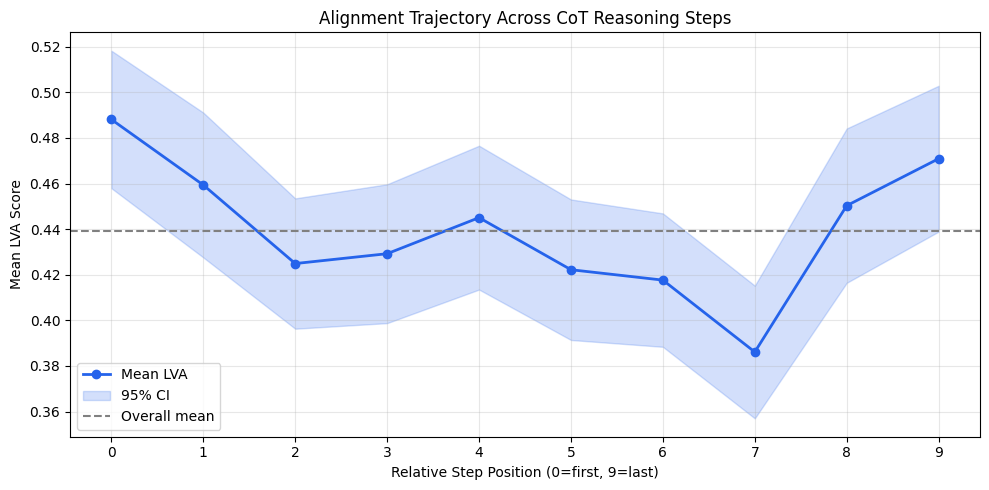

Saved trajectory plot


In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Trajectory: mean LVA by relative position decile
step_lva_spec["decile"] = pd.cut(
    step_lva_spec["rel_step_pos"], 
    bins=10, 
    labels=[f"{i}" for i in range(10)]
)

trajectory = (
    step_lva_spec.groupby("decile")["lva_score"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
trajectory["se"] = trajectory["std"] / np.sqrt(trajectory["count"])

print("Trajectory: Mean LVA by relative position decile")
print(trajectory[["decile", "mean", "se", "count"]].round(3).to_string())

# Test for monotonic trend
from scipy.stats import spearmanr
r, p = spearmanr(range(len(trajectory)), trajectory["mean"])
print(f"\nSpearman correlation with position: r={r:.3f}, p={p:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trajectory["decile"], trajectory["mean"], 
        marker="o", linewidth=2, color="#2563EB", label="Mean LVA")
ax.fill_between(
    trajectory["decile"],
    trajectory["mean"] - 1.96 * trajectory["se"],
    trajectory["mean"] + 1.96 * trajectory["se"],
    alpha=0.2, color="#2563EB", label="95% CI"
)
ax.axhline(y=step_lva_spec["lva_score"].mean(), 
           color="gray", linestyle="--", label="Overall mean")
ax.set_xlabel("Relative Step Position (0=first, 9=last)")
ax.set_ylabel("Mean LVA Score")
ax.set_title("Alignment Trajectory Across CoT Reasoning Steps")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(CACHE_DIR / "trajectory_plot.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved trajectory plot")

In [35]:
from scipy.stats import ttest_ind

# Test: early steps (0-1) vs middle steps (5-7) vs late steps (8-9)
early  = step_lva_spec[step_lva_spec["decile"].astype(int) <= 1]["lva_score"]
middle = step_lva_spec[step_lva_spec["decile"].astype(int).between(5, 7)]["lva_score"]
late   = step_lva_spec[step_lva_spec["decile"].astype(int) >= 8]["lva_score"]

t_em, p_em = ttest_ind(early, middle, equal_var=False)
t_ml, p_ml = ttest_ind(middle, late, equal_var=False)
t_el, p_el = ttest_ind(early, late, equal_var=False)

print(f"Early mean:  {early.mean():.3f} (n={len(early)})")
print(f"Middle mean: {middle.mean():.3f} (n={len(middle)})")
print(f"Late mean:   {late.mean():.3f} (n={len(late)})")
print(f"\nEarly vs Middle:  t={t_em:.3f}, p={p_em:.4f}")
print(f"Middle vs Late:   t={t_ml:.3f}, p={p_ml:.4f}")
print(f"Early vs Late:    t={t_el:.3f}, p={p_el:.4f}")

Early mean:  0.474 (n=368)
Middle mean: 0.408 (n=551)
Late mean:   0.461 (n=366)

Early vs Middle:  t=4.580, p=0.0000
Middle vs Late:   t=-3.552, p=0.0004
Early vs Late:    t=0.780, p=0.4355


In [ ]:
# Cell 0 — after setting the key
import os
import importlib

# os.environ["ANTHROPIC_API_KEY"] 

# Force reload so the new module-level code runs with the key set
import sys
for mod in ["scoring"]:
    if mod in sys.modules:
        del sys.modules[mod]

from scoring import (apply_label_filter, stratified_step_sample,
                     run_scoring, compute_step_lva,
                     compute_baselines, run_h1_tests,
                     run_consistency_check)

# Verify
from scoring import judge_pair
test = judge_pair("x = 5 + 3 = 8", "Mathematical calculation steps")
print(test)

{'score': -1.0, 'confidence': 'error', 'reasoning': "Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CZy3V7SyGvpcnbwjhT5kW'}"}


In [5]:
import os

run1 = CACHE_DIR / "lva_consistency_run1.parquet"
run2 = CACHE_DIR / "lva_consistency_rescore.parquet"

for f in [run1, run2]:
    if f.exists():
        os.remove(f)
        print(f"Deleted: {f}")

r = run_consistency_check(
    scoring_df,
    cache_path=CACHE_DIR / "lva_consistency_rescore.parquet",
    force=True
)

Deleted: /content/drive/MyDrive/latent_verbal_gap/checkpoints/lva_consistency_run1.parquet
Deleted: /content/drive/MyDrive/latent_verbal_gap/checkpoints/lva_consistency_rescore.parquet


Consistency run 2: 100%|██████████| 99/99 [01:00<00:00,  1.65it/s]


ValueError: `x` and `y` must have length at least 2.

In [6]:
run1 = pd.read_parquet(CACHE_DIR / "lva_consistency_run1.parquet")
run2 = pd.read_parquet(CACHE_DIR / "lva_consistency_rescore.parquet")

print("Run 1 columns:", run1.columns.tolist())
print("Run 2 columns:", run2.columns.tolist())
print("Run 1 shape:", run1.shape)
print("Run 2 shape:", run2.shape)
print("\nRun 1 sample:")
print(run1.head(3))
print("\nRun 2 sample:")
print(run2.head(3))

# Check overlap on merge keys
merged = run1.merge(run2, on=["sequence_id", "step_idx", "feature_id"], how="inner")
print(f"\nMerged rows: {len(merged)}")

Run 1 columns: ['sequence_id', 'step_idx', 'feature_id', 'lva_score']
Run 2 columns: ['sequence_id', 'step_idx', 'feature_id', 'lva_score']
Run 1 shape: (99, 4)
Run 2 shape: (99, 4)

Run 1 sample:
   sequence_id  step_idx  feature_id  lva_score
0         2000        82       10528       -1.0
1        41000         9        7464       -1.0
2        48000       389        7464       -1.0

Run 2 sample:
   sequence_id  step_idx  feature_id  lva_score
0         2000        82       10528       -1.0
1        72000       303       15072       -1.0
2        48000       389        7464       -1.0

Merged rows: 99


In [52]:
# Save all key results for next session
import json

session_state = {
    "scores_df_path": str(CACHE_DIR / "lva_scores_raw.parquet"),
    "step_lva_path": str(CACHE_DIR / "step_lva_scores.parquet"),
    "h1_path": str(CACHE_DIR / "h1_comparison.parquet"),
    "trajectory_plot": str(CACHE_DIR / "trajectory_plot.png"),
    "key_results": {
        "h1": "null - generic features dominate, step-shuffle d=0.000",
        "h2": "supported opposite direction - ANOVA p=0.021, uncertainty>setup>calc>selfcorrect",
        "h3": "partial - 2 silent features, #23364 commas, #15924 circles",
        "trajectory": "U-shape - early=0.474, middle=0.408, late=0.461, early_vs_mid p<0.0001"
    }
}

with open(str(CACHE_DIR / "session_state.json"), "w") as f:
    json.dump(session_state, f, indent=2)
print("Session state saved")
print(json.dumps(session_state["key_results"], indent=2))

Session state saved
{
  "h1": "null - generic features dominate, step-shuffle d=0.000",
  "h2": "supported opposite direction - ANOVA p=0.021, uncertainty>setup>calc>selfcorrect",
  "h3": "partial - 2 silent features, #23364 commas, #15924 circles",
  "trajectory": "U-shape - early=0.474, middle=0.408, late=0.461, early_vs_mid p<0.0001"
}


In [53]:
# ============================================================
# FIXED STEP-SHUFFLE BASELINE
# Drop-in replacement for cells 19-22 in step02_scoring.ipynb
#
# What was wrong:
#   The old shuffle rotated step_idx values but kept lva_score
#   attached to those rows — so the "shuffled" scores were
#   identical to the real scores (confirmed: t=0.000, d=0.000).
#
# What this does instead:
#   1. Keep every (sequence_id, step_idx, feature_id) row as-is.
#   2. Replace step_text with the NEXT step's text in the same
#      sequence (cyclic: last step wraps to first).
#   3. Rescore those (feature_label, shuffled_text) pairs through
#      the judge — producing genuinely mismatched LVA scores.
#   4. Aggregate to step level and run H1 t-test vs real scores.
# ============================================================

import os
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats as scipy_stats
from tqdm import tqdm

from config import CACHE_DIR, RNG_SEED
from scoring import judge_pair


# ------------------------------------------------------------------
# 0. Guard: abort if real scores aren't loaded
# ------------------------------------------------------------------
assert "scores_specific" in dir(), (
    "scores_specific not found — run the filter+scoring cells first."
)
assert "scoring_df" in dir(), (
    "scoring_df not found — run the setup cell first."
)
assert "step_lva_spec" in dir(), (
    "step_lva_spec not found — run the step-level aggregation cell first."
)



In [56]:

# ------------------------------------------------------------------
# 1. Build the shuffled-text dataframe
#    For each sequence: step i gets the text that belongs to step i+1.
#    (Last step wraps around to step 0's text — cyclic shift.)
# ------------------------------------------------------------------
def attach_next_step_text(group: pd.DataFrame) -> pd.DataFrame:
    """
    Given a group for one sequence_id, add a 'shuffled_text' column
    where each row's text is the text of the NEXT step in the trace.
    """
    g = group.copy()
    # One row per step (sorted), to build the step→text mapping
    step_order = (
        g.drop_duplicates("step_idx")
         .sort_values("step_idx")[["step_idx", "step_text"]]
         .reset_index(drop=True)
    )
    n = len(step_order)
    if n < 2:
        # Only one step in this sequence — can't shuffle meaningfully;
        # mark as NaN so we can drop it later.
        g["shuffled_text"] = np.nan
        return g
 
    # Cyclic shift: index i → text of index (i+1) % n
    next_text = step_order["step_text"].iloc[
        [(i + 1) % n for i in range(n)]
    ].values
    text_map = dict(zip(step_order["step_idx"], next_text))
    g["shuffled_text"] = g["step_idx"].map(text_map)
    return g
 
 
# Merge step_text into scores_specific (needed to build the mapping)
scores_with_text = scores_specific.merge(
    scoring_df[["sequence_id", "step_idx", "feature_id", "step_text"]],
    on=["sequence_id", "step_idx", "feature_id"],
    how="left",
)
 
scores_shuffled_text = (
    scores_with_text
    .groupby("sequence_id", group_keys=False)
    .apply(attach_next_step_text, include_groups=True)
    .dropna(subset=["shuffled_text"])          # drop single-step sequences
    .reset_index(drop=True)
)
 
# Drop the one row where shuffled_text == step_text (consecutive identical steps).
# Keeping it would give the judge the correct text under the shuffle condition,
# inflating the baseline and making H1 harder to pass — conservative to drop.
identical_mask = scores_shuffled_text["step_text"] == scores_shuffled_text["shuffled_text"]
n_same = identical_mask.sum()
if n_same > 0:
    print(f"Dropping {n_same} row(s) where shuffled_text == step_text "
          f"(consecutive identical steps — not a meaningful shuffle).")
    scores_shuffled_text = scores_shuffled_text[~identical_mask].reset_index(drop=True)
 
print(f"Total rows to rescore: {len(scores_shuffled_text):,}")
 
 
 

Dropping 1 row(s) where shuffled_text == step_text (consecutive identical steps — not a meaningful shuffle).
Total rows to rescore: 3,521


/tmp/ipykernel_1850/814289312.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(attach_next_step_text, include_groups=True)


In [ ]:

# ------------------------------------------------------------------
# 2. Rescore through the judge
#    We score (feature_label, shuffled_text) — NOT the original text.
#    Cache so the run is resumable.
# ------------------------------------------------------------------
SHUFFLE_CACHE = CACHE_DIR / "lva_shuffle_rescored.parquet"
FORCE_RESCORE = False   # set True to ignore cache and rescore from scratch
 
 
def rescore_shuffled(df: pd.DataFrame, cache_path: Path, force: bool = False) -> pd.DataFrame:
    """
    Score each (feature_label, shuffled_text) pair through judge_pair.
    Saves results incrementally to cache_path.
    Returns a dataframe with columns:
        sequence_id, step_idx, feature_id, lva_score_shuffled
    """
    if not force and cache_path.exists():
        cached = pd.read_parquet(cache_path)
        print(f"Loaded {len(cached):,} shuffled scores from cache.")
        return cached
 
    records = []
    errors  = 0
 
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Shuffle rescore"):
        result = judge_pair(row["shuffled_text"], row["feature_label"])
        score  = result.get("score", -1.0)
        if score < 0:
            errors += 1
        records.append({
            "sequence_id":       row["sequence_id"],
            "step_idx":          row["step_idx"],
            "feature_id":        row["feature_id"],
            "strength_w":        row["strength_w"],
            "lva_score_shuffled": score,
        })
 
    result_df = pd.DataFrame(records)
    result_df.to_parquet(cache_path, index=False)
    print(f"Saved {len(result_df):,} rows. Errors (score=-1): {errors}")
    return result_df
 
 
shuffled_scores = rescore_shuffled(
    scores_shuffled_text,
    cache_path=SHUFFLE_CACHE,
    force=FORCE_RESCORE,
)
 

Shuffle rescore:   1%|          | 22/3521 [00:32<1:14:35,  1.28s/it]

Shuffle rescore:   1%|          | 23/3521 [00:34<1:25:06,  1.46s/it]

: 

In [ ]:


# ------------------------------------------------------------------
# 2. Rescore through the judge
#    We score (feature_label, shuffled_text) — NOT the original text.
#    Cache so the run is resumable.
# ------------------------------------------------------------------
SHUFFLE_CACHE = CACHE_DIR / "lva_shuffle_rescored.parquet"
FORCE_RESCORE = False   # set True to ignore cache and rescore from scratch


def rescore_shuffled(df: pd.DataFrame, cache_path: Path, force: bool = False) -> pd.DataFrame:
    """
    Score each (feature_label, shuffled_text) pair through judge_pair.
    Saves results incrementally to cache_path.
    Returns a dataframe with columns:
        sequence_id, step_idx, feature_id, lva_score_shuffled
    """
    if not force and cache_path.exists():
        cached = pd.read_parquet(cache_path)
        print(f"Loaded {len(cached):,} shuffled scores from cache.")
        return cached

    records = []
    errors  = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Shuffle rescore"):
        result = judge_pair(row["shuffled_text"], row["feature_label"])
        score  = result.get("score", -1.0)
        if score < 0:
            errors += 1
        records.append({
            "sequence_id":       row["sequence_id"],
            "step_idx":          row["step_idx"],
            "feature_id":        row["feature_id"],
            "strength_w":        row["strength_w"],
            "lva_score_shuffled": score,
        })

    result_df = pd.DataFrame(records)
    result_df.to_parquet(cache_path, index=False)
    print(f"Saved {len(result_df):,} rows. Errors (score=-1): {errors}")
    return result_df


shuffled_scores = rescore_shuffled(
    scores_shuffled_text,
    cache_path=SHUFFLE_CACHE,
    force=FORCE_RESCORE,
)


# ------------------------------------------------------------------
# 3. Aggregate to step level
# ------------------------------------------------------------------
def aggregate_to_step_level(scored_df: pd.DataFrame, score_col: str) -> np.ndarray:
    """
    Strength-weighted mean of score_col per (sequence_id, step_idx).
    Returns a 1-D array of step-level scores.
    """
    valid = scored_df[scored_df[score_col] >= 0].copy()
    step_scores = (
        valid
        .groupby(["sequence_id", "step_idx"])
        .apply(
            lambda g: (g["strength_w"] * g[score_col]).sum() / g["strength_w"].sum(),
            include_groups=False,
        )
        .values
    )
    return step_scores


real_step_scores    = step_lva_spec["lva_score"].values
shuffled_step_scores = aggregate_to_step_level(shuffled_scores, "lva_score_shuffled")

print(f"\nReal step scores:     n={len(real_step_scores)}, "
      f"mean={real_step_scores.mean():.3f}, std={real_step_scores.std():.3f}")
print(f"Shuffled step scores: n={len(shuffled_step_scores)}, "
      f"mean={shuffled_step_scores.mean():.3f}, std={shuffled_step_scores.std():.3f}")


# ------------------------------------------------------------------
# 4. H1 test: real vs corrected step-shuffle
# ------------------------------------------------------------------
def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    pooled = np.sqrt((np.std(a, ddof=1) ** 2 + np.std(b, ddof=1) ** 2) / 2)
    return float((np.mean(a) - np.mean(b)) / pooled) if pooled > 0 else 0.0


t, p = scipy_stats.ttest_ind(real_step_scores, shuffled_step_scores, equal_var=False)
d    = cohens_d(real_step_scores, shuffled_step_scores)
sig  = "✓ SIGNIFICANT" if p < 0.05 and abs(d) > 0.3 else "✗ not significant"

print(f"\n{'='*60}")
print(f"H1: Real LVA vs CORRECTED step-shuffle baseline")
print(f"{'='*60}")
print(f"  real    mean={real_step_scores.mean():.3f}  "
      f"n={len(real_step_scores)}")
print(f"  shuffle mean={shuffled_step_scores.mean():.3f}  "
      f"n={len(shuffled_step_scores)}")
print(f"  Welch t={t:.3f}  p={p:.4f}  Cohen's d={d:.3f}")
print(f"  {sig}")
print()
print("Interpretation:")
if p < 0.05 and d > 0.3:
    print("  Real LVA is significantly above shuffled baseline — features")
    print("  are more aligned with their own step text than with a neighbor's.")
elif p < 0.05 and d < -0.3:
    print("  Shuffled baseline EXCEEDS real LVA — unexpected; check for")
    print("  sequence-level confounds or feature genericity.")
elif p >= 0.05:
    print("  No significant difference from shuffled baseline.")
    print("  This is a genuine null result for H1 — SAE features are not")
    print("  more aligned with their own step than with an adjacent step.")
    print("  Likely driven by feature genericity (label_quality check advised).")


# ------------------------------------------------------------------
# 5. Quick sanity check: Feature #7483 on its known-positive step
#    vs the same feature on the shuffled (adjacent) step
# ------------------------------------------------------------------
FEATURE_7483_LABEL = "Self-correction when realizing a mistake in reasoning"

f7483_rows = scores_shuffled_text[
    scores_shuffled_text["feature_label"] == FEATURE_7483_LABEL
]
if len(f7483_rows) > 0:
    print(f"\n{'='*60}")
    print("Sanity check: Feature #7483 — original vs shuffled text")
    print(f"{'='*60}")
    for _, row in f7483_rows.head(3).iterrows():
        orig_score = scores_specific.loc[
            (scores_specific["sequence_id"] == row["sequence_id"]) &
            (scores_specific["step_idx"]    == row["step_idx"]) &
            (scores_specific["feature_id"]  == row["feature_id"]),
            "lva_score"
        ].values
        shuf_result = judge_pair(row["shuffled_text"], FEATURE_7483_LABEL)
        print(f"  seq={row['sequence_id']} step={row['step_idx']}")
        print(f"  Original text:  {row['step_text'][:120]}")
        print(f"  Original score: {orig_score[0] if len(orig_score) else 'N/A'}")
        print(f"  Shuffled text:  {row['shuffled_text'][:120]}")
        print(f"  Shuffled score: {shuf_result.get('score', 'error')}")
        print()
else:
    print("\nFeature #7483 not present in scores_specific (filtered out or absent).")
    print("Run the known-positive sanity check manually with judge_pair().")